# SkyGrid AI: An AI model to detect defects in power distribution assets

This notebook explores the Convolution Neural Network (CNN) for inspection and classification of power line assets. The project aims to facilitate research and development in automated defect detection for critical infrastructure.

In this particular application, we focus on leveraging the InsPLAD dataset to train and evaluate a deep learning model for the **detection of rust (corrosion)** on power line components. Early and accurate detection of such defects is crucial for preventative maintenance, ensuring grid reliability, reducing operational costs, and most importantly to avoid damages caused by wildfires. We demonstrate a complete pipeline from data preparation and model training to evaluation and visualization of predictions on unseen data.

## Resources

### InsPLAD dataset, a comprehensive collection of UAV imagery

@article{doi:10.1080/01431161.2023.2283900,
   author    = {André Luiz Buarque Vieira e Silva, Heitor de Castro Felix, Franscisco Paulo Magalhães Simões, Veronica Teichrieb, Michel dos Santos, Hemir Santiago, Virginia Sgotti and Henrique Lott Neto},
   title     = {InsPLAD: A Dataset and Benchmark for Power Line Asset Inspection in UAV Images},
   journal   = {International Journal of Remote Sensing},
   volume    = {44},
   number    = {23},
   pages     = {1-27},
   year      = {2023},
   publisher = {Taylor & Francis},
   doi       = {10.1080/01431161.2023.2283900},
   URL       = {https://doi.org/10.1080/01431161.2023.2283900},
   eprint    = {https://doi.org/10.1080/01431161.2023.2283900},
}

@InProceedings{Vieira_2024_WACV,
    author    = {e Silva, Andr\'e Luiz Vieira and Sim\~oes, Francisco and Kowerko, Danny and Schlosser, Tobias and Battisti, Felipe and Teichrieb, Veronica},
    title     = {Attention Modules Improve Image-Level Anomaly Detection for Industrial Inspection: A DifferNet Case Study},
    booktitle = {Proceedings of the IEEE/CVF Winter Conference on Applications of Computer Vision (WACV)},
    month     = {January},
    year      = {2024},
    pages     = {8246-8255}
}

## Setup

 So, 

- 


## Setup & Data Extraction
- The image files to train the model are huge in number
- Below cell unzips the dataset and prepares the file system for data loading.

In [ ]:
# 1. Clean out the old session directory
!rm -rf yoke-suspension-data

# 2. Unzip your master file
!unzip -q yoke-suspension-data.zip

print("Extraction complete! Ready for clean DataFrame mapping.")


Extraction complete! Ready for clean DataFrame mapping.


In [ ]:
import os

import pandas as pd
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight
from keras.preprocessing import image # For image loading in widget


## Build DataFrames
This cell defines a function to build clean DataFrames from specified directories, ensuring correct labels, and then applies it to create training and validation sets.

In [ ]:
def build_clean_dataframe(parent_dir):
    """Scans ONLY the exact target child subdirectories to enforce clean labels."""
    data_list = []

    # Target the true supervised layout subfolders
    good_dir = os.path.join(parent_dir, "good")
    rust_dir = os.path.join(parent_dir, "rust") # Or change to "defect" if named that way in the pane

    if os.path.exists(good_dir):
        for f in os.listdir(good_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                data_list.append({'path': os.path.join(good_dir, f), 'label': 'good'})

    if os.path.exists(rust_dir):
        for f in os.listdir(rust_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                data_list.append({'path': os.path.join(rust_dir, f), 'label': 'rust'})

    return pd.DataFrame(data_list)

# 1. MAP DATASETS DIRECTLY FROM THE DEFECT_SUPERVISED SUITE
# Note: Adjust the mid-string folder layout if your zip structure is nested
TRAIN_PATH = "./yoke-suspension-data/train"
VAL_PATH = "./yoke-suspension-data/val"

train_df = build_clean_dataframe(TRAIN_PATH)
val_df = build_clean_dataframe(VAL_PATH)

# Shuffle datasets
train_df = train_df.sample(frac=1, random_state=123).reset_index(drop=True)
val_df = val_df.sample(frac=1, random_state=123).reset_index(drop=True)

print(f"Data Mapped Natively! -> Training Frames: {len(train_df)} | Validation Frames: {len(val_df)}")


Data Mapped Natively! -> Training Frames: 589 | Validation Frames: 5762


## Data Preprocessing and Pipelining
This cell defines image loading and preprocessing steps, converting images to a suitable format for the neural network and creating efficient data pipelines using TensorFlow's `tf.data.Dataset`.

In [ ]:
# 1. CONSTANTS
IMG_SIZE = (300, 300)
BATCH_SIZE = 32
EPOCHS = 15

def load_and_preprocess(path, label):
    img_raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0

    numeric_label = tf.where(tf.equal(label, "rust"), 1, 0)
    return img, numeric_label

# Build clean independent pipelines
train_paths_ds = tf.data.Dataset.from_tensor_slices((train_df['path'].values, train_df['label'].values))
train_ds = train_paths_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_paths_ds = tf.data.Dataset.from_tensor_slices((val_df['path'].values, val_df['label'].values))
val_ds = val_paths_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Keras tensor pipelines successfully isolated!")


Keras tensor pipelines successfully isolated!


## Model Definition and Training
This cell defines the convolutional neural network (CNN) architecture, compiles the model with an optimizer and loss function, and then trains the model using the prepared training and validation datasets.

In [ ]:
def build_custom_cnn():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

        # # Augmentations force the model to ignore background noise shifts
        # layers.RandomFlip("horizontal_and_vertical"),
        # layers.RandomContrast(0.2),
        # layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid') # 0 = GOOD, 1 = RUST
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Rebuild a fresh instance of the model
custom_model = build_custom_cnn()

print("Training optimized model natively on balanced datasets...")
history = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Training optimized model natively on balanced datasets...
Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.6452 - loss: 0.6188 - val_accuracy: 0.9408 - val_loss: 0.3635
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.8472 - loss: 0.3730 - val_accuracy: 0.9516 - val_loss: 0.2205
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9117 - loss: 0.2613 - val_accuracy: 0.9632 - val_loss: 0.1739
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9338 - loss: 0.1995 - val_accuracy: 0.9368 - val_loss: 0.2138
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9355 - loss: 0.1726 - val_accuracy: 0.8839 - val_loss: 0.3226
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9474 - loss: 0.1488 - val_accuracy: 0.9422 - val_loss: 0.1843
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9711 - loss: 0.1178 - val_accuracy: 0.9832 - val_loss: 0.0719
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms

## Model Performance Evaluation
This cell defines a function to evaluate the model's performance using a classification report and a confusion matrix, then applies it to the trained model and validation data.

Extracting test predictions...

================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

        Good       1.00      0.96      0.98      5742
        Rust       0.05      0.65      0.10        20

    accuracy                           0.96      5762
   macro avg       0.53      0.80      0.54      5762
weighted avg       1.00      0.96      0.98      5762




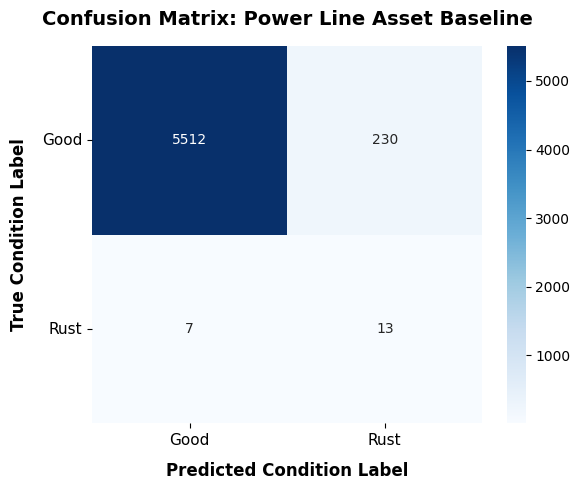

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model_performance(model, val_ds, target_names):
    """Evaluates a given model's performance on the validation dataset."""
    # 1. EXTRACT TRUE LABELS AND MODEL PREDICTIONS FROM THE TEST DATASET
    y_true = []
    y_pred = []

    print("Extracting test predictions...")
    # Iterate through the test dataset batches
    for images, labels in val_ds:
        y_true.extend(labels.numpy())
        # Generate continuous raw sigmoid scores (0.0 to 1.0)
        preds = model.predict(images, verbose=0)
        # Threshold at 0.5: scores >= 0.5 become 1 (Rust), < 0.5 become 0 (Good)
        y_pred.extend((preds >= 0.5).astype(int))

    # Convert lists to clean numpy arrays for sklearn metrics
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    # 2. GENERATE AND PRINT THE CLASSIFICATION REPORT
    print('\n================ CLASSIFICATION REPORT ================')
    print(classification_report(y_true, y_pred, target_names=target_names))
    print('=======================================================\n')

    # 3. COMPUTE AND PLOT THE VISUAL CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,          # Writes the raw count numbers inside the squares
        fmt='d',             # Enforces standard integer formatting (no decimals)
        cmap='Blues',        # Beautiful color gradient theme
        xticklabels=target_names,
        yticklabels=target_names,
        cbar=True            # Adds the color magnitude scale bar on the right
    )

    # Style formatting for a publication/portfolio-ready plot
    plt.xlabel('Predicted Condition Label', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('True Condition Label', fontsize=12, fontweight='bold', labelpad=10)
    plt.title('Confusion Matrix: Power Line Asset Baseline', fontsize=14, fontweight='bold', pad=15)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11, rotation=0) # Keeps 'True' labels upright and scannable
    plt.tight_layout()
    plt.show()

# Define explicit target text names matching your mapping (0=Good, 1=Rust)
target_names = ['Good', 'Rust']

# Run the evaluation using your custom model
evaluate_model_performance(custom_model, val_ds, target_names)

## Prediction Function from File Path
This cell defines a utility function `predict_from_path` that takes an image file path and the trained model to predict whether the image shows 'good' or 'rust' condition.

In [ ]:
def predict_from_path(file_path, trained_model, threshold=0.5):
    # Preprocess to match training constraints (150x150)
    img = image.load_img(file_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)

    # Pull output probability array score
    prediction_score = trained_model.predict(img_batch, verbose=0)[0][0]

    # Model maps 0 = GOOD, 1 = RUST. Score closer to 0 is GOOD, closer to 1 is RUST.
    if prediction_score >= threshold:
        label = "RUST (Defect Detected)"
        confidence = prediction_score * 100
        text_color = "red"
    else:
        label = "GOOD (Asset Normal)"
        confidence = (1 - prediction_score) * 100
        text_color = "green"

    return img, label, confidence, text_color, prediction_score

print("Predict from path function created.")

Predict from path function created.


## Test Image Prediction and Visualization
This cell loads sample images from the test dataset, uses the `predict_from_path` function to get predictions, and then displays the images along with their predictions and confidence scores in a subplot for visual inspection.

Evaluating 6 test images...


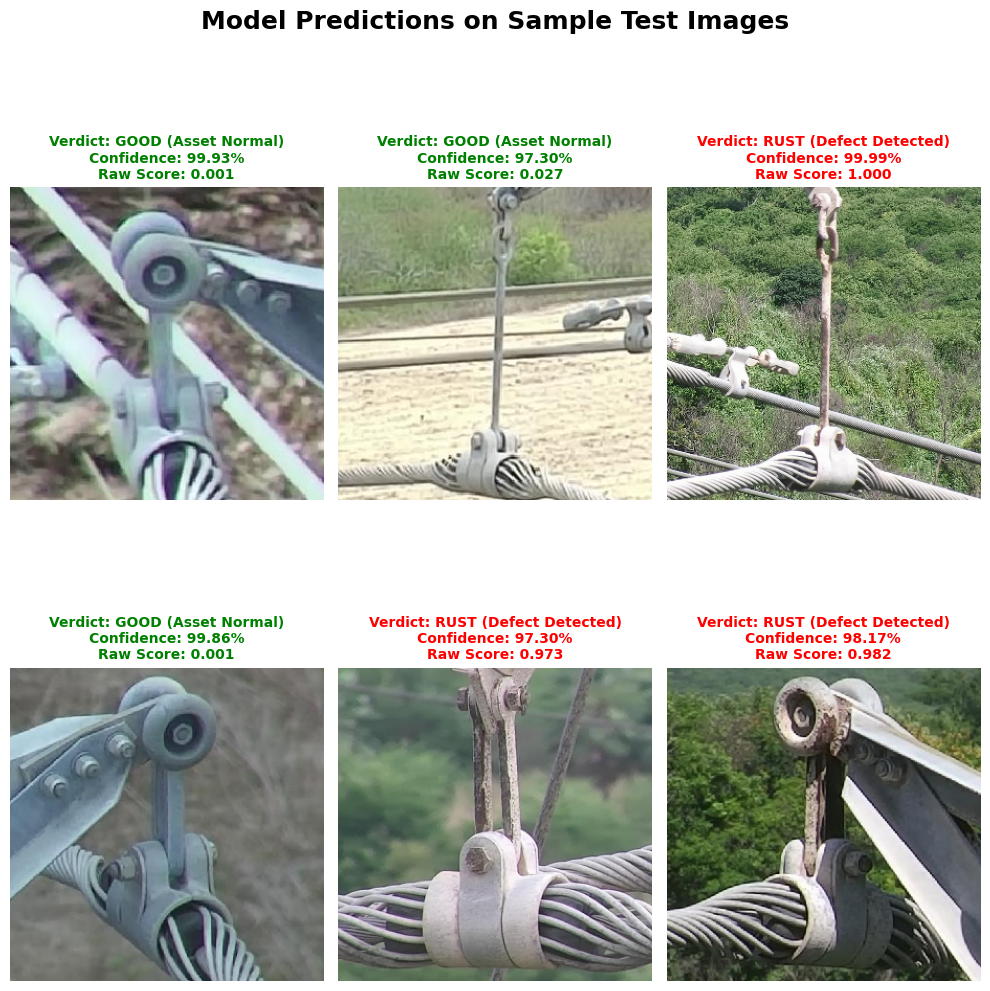

In [ ]:
# Define the path to the test dataset
TEST_PATH = "./yoke-suspension-data/test"

# Get lists of good and rust image paths
good_test_dir = os.path.join(TEST_PATH, "good")
rust_test_dir = os.path.join(TEST_PATH, "rust")

good_images = [os.path.join(good_test_dir, f) for f in os.listdir(good_test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
rust_images = [os.path.join(rust_test_dir, f) for f in os.listdir(rust_test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Select 3 random good and 3 random rust images
selected_good_images = np.random.choice(good_images, 3, replace=False)
selected_rust_images = np.random.choice(rust_images, 3, replace=False)

# Combine and shuffle for display
all_selected_images = list(selected_good_images) + list(selected_rust_images)
np.random.shuffle(all_selected_images)

# Create a subplot for displaying predictions
fig, axes = plt.subplots(2, 3, figsize=(10, 10))
plt.subplots_adjust(hspace=0.8)
axes = axes.flatten()

print(f"Evaluating {len(all_selected_images)} test images...")

for i, img_path in enumerate(all_selected_images):
    img_display, label, confidence, text_color, raw_score = predict_from_path(img_path, custom_model, threshold=0.5)

    axes[i].imshow(img_display)
    axes[i].set_title(f"Verdict: {label}\nConfidence: {confidence:.2f}%\nRaw Score: {raw_score:.3f}", color=text_color, fontweight='bold', fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Model Predictions on Sample Test Images', y=1.06, fontsize=18, fontweight='bold')
plt.show()